### <font color=skyblue>Prepare and observe the AT&T face image data before training</font>

- Original faces
- Eignefaces
- Reconstructed faces from Eigenfaces

<font color=red>注意：之後將分別使用原始影像與特徵臉(Eigenfaces)進行人臉識別訓練，並比較兩者的效果。</font>

<hr>

<font color=yellow>Load and check the image data</font>

人臉影像資料的儲存格式沒有固定規則，通常會根據不同的應用需求和資料來源而有所不同。必須先觀察資料的特性，來決定如何處理和使用影像資料。

In [7]:
import numpy as np
import pandas as pd

df = pd.read_csv('data/face_data.csv')
n_persons = df['target'].nunique() 
X = np.array(df.drop('target', axis=1)) # 400 x 4096
y = np.array(df['target'])

print(f"Number of persons: {n_persons}")
print(f"Shape of X: {X.shape}") # (samples, features)
print(f"Shape of y: {y.shape}")

Number of persons: 40
Shape of X: (400, 4096)
Shape of y: (400,)


<font color=yellow>Display the image data</font>

常見以蒙太奇(montage)方式呈現影像資料，將多張影像排列在同一個畫面中，方便觀察影像資料的特性。

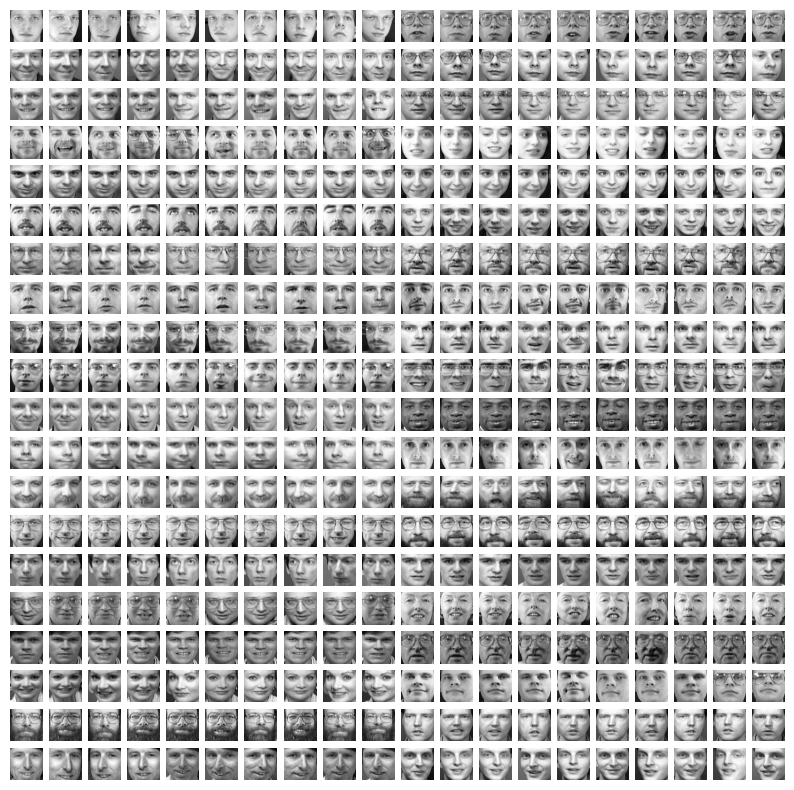

In [8]:
# display the images in X in a grid of 20 x 20
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(400):
    plt.subplot(20, 20, i + 1)
    plt.imshow(X[i].reshape(64, 64), cmap='gray')
    plt.axis('off')
plt.show()

<font color=yellow>Display the images in a montage frame</font>

以下是較有效率的方式。

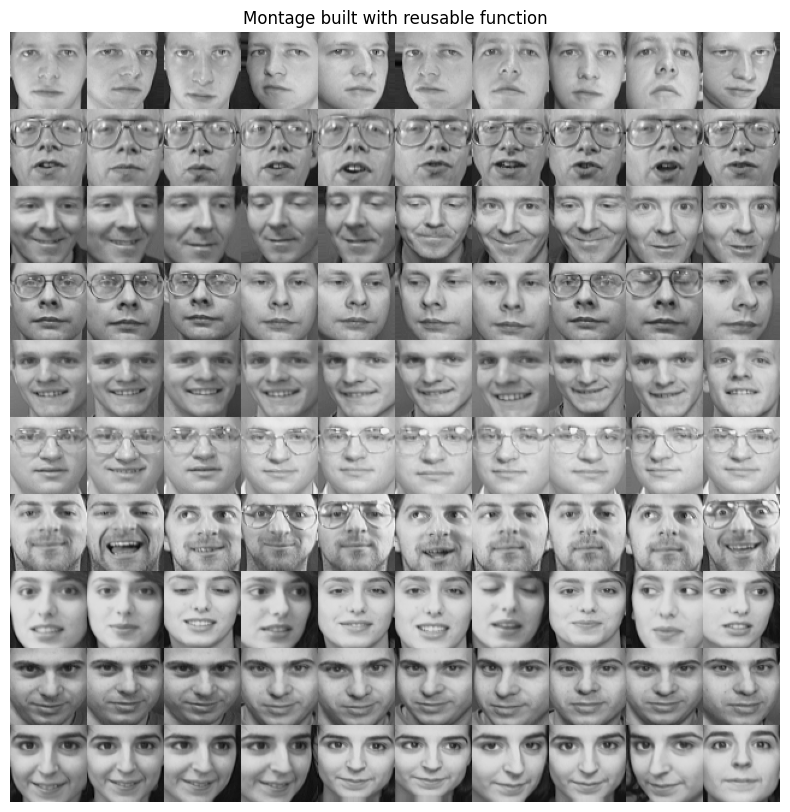

In [10]:
# Generalize into a Reusable Function
def build_montage(X, img_h, img_w, m, n):
    """
    Rearrange a flattened image array X (N x (img_h*img_w)) into an
    m x n montage matrix of shape (m*img_h, n*img_w).

    Parameters
    ----------
    X : np.ndarray
        Array of shape (N, img_h*img_w) containing flattened images.
    img_h, img_w : int
        Height and width of each individual image.
    m, n : int
        Number of rows and columns in the montage grid.

    Returns
    -------
    montage : np.ndarray
        2D array of shape (m*img_h, n*img_w) representing the montage.
    """
    assert m * n <= X.shape[0], f"m*n ({m*n}) exceeds number of images in X ({X.shape[0]})"
    grid = X[:m * n].reshape(m, n, img_h, img_w)
    montage = grid.transpose(0, 2, 1, 3).reshape(m * img_h, n * img_w)
    return montage

# Example usage:
img_h, img_w = 64, 64
m, n = 10, 10
montage_2 = build_montage(X, img_h, img_w, m, n)
plt.figure(figsize=(10, 10))
plt.imshow(montage_2, cmap='gray')
plt.axis('off')
plt.title("Montage built with reusable function")
plt.show()


<font color=yellow>從每個人的 10 張照片中，隨機選擇 1 張照片，並將這些照片顯示在一個 4 x 10 的網格中</font>

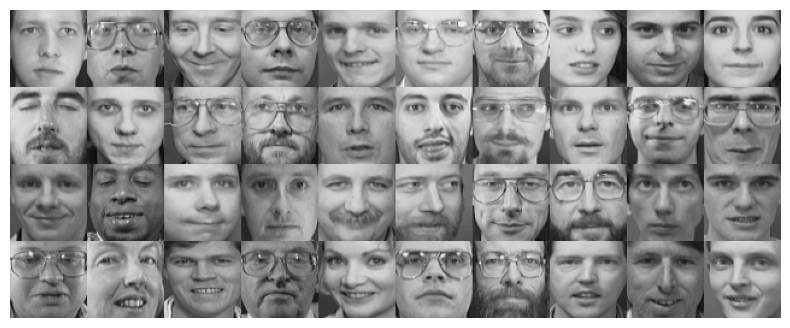

In [11]:
# 從每個人的 10 張照片中，隨機選擇 1 張照片，並將這些照片顯示在一個 4 x 10 的網格中
import matplotlib.pyplot as plt

# 隨機選擇 1 張照片
selected_images = []
for i in range(n_persons):
    idx = np.random.choice(np.where(y == i)[0])
    selected_images.append(X[idx])


# 顯示在一個 4 x 10 的網格中
# use build_montage function to create a montage of the selected images
montage_selected = build_montage(np.array(selected_images), img_h, img_w, 4, 10)
plt.figure(figsize=(10, 4))
plt.imshow(montage_selected, cmap='gray')
plt.axis('off')
plt.show()
# fig, axes = plt.subplots(4, 10, figsize=(10, 4))
# for i in range(4):
#     for j in range(10):
#         axes[i, j].imshow(selected_images[i * 10 + j].reshape(img_h, img_w), cmap='gray')
#         axes[i, j].axis('off')
# plt.show()

<font color=yellow>Eigenfaces</font>

Eigenfaces 指的是從人臉影像資料中提取出來的特徵臉，也就是透過主成分分析(PCA)方法，將原始影像資料轉換成一組特徵向量（eigenvectors），也稱主成分（principal components）。因為它們能夠捕捉到人臉的主要變化特徵，可以用來進行人臉識別。

<font color=yellow>Derive the eignevectors of the face images</font>

The eigenfaces are the eigenvectors of the covariance matrix of the face images. 

注意： eigenvectors 的維度與人臉影像相同，因此可以觀察出內涵的影像訊息。

Eigenfaces shape: (20, 4096)
Explained variance ratio (first 10): [0.23812729 0.13993971 0.07968614 0.04998331 0.03609848 0.03156939
 0.02426832 0.02036398 0.01958114 0.01672122]
Total explained variance (first 20 components): 0.7634


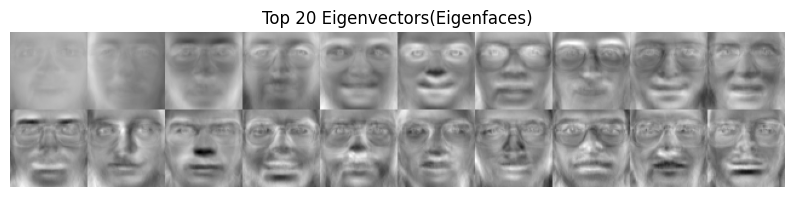

In [14]:
# derive and display the eigenvectors of the image data using PCA
from sklearn.decomposition import PCA

n_components = 20  # number of eigenfaces to compute

pca = PCA(n_components=n_components, whiten=True, random_state=42)
pca.fit(X)

eigen_vec = pca.components_  # shape: (n_components, img_h*img_w)

print(f"Eigenfaces shape: {eigen_vec.shape}")
print(f"Explained variance ratio (first 10): {pca.explained_variance_ratio_[:10]}")
print(f"Total explained variance (first {n_components} components): {pca.explained_variance_ratio_.sum():.4f}")

# Display the top eigenfaces using the montage function
n_display = n_components  # display first 25 eigenfaces (5x5 grid)
m, n = 2, 10
montage_eigen_vec = build_montage(eigen_vec, img_h, img_w, m, n)

plt.figure(figsize=(10, 10))
plt.imshow(255-montage_eigen_vec, cmap='gray')
plt.axis('off')
plt.title(f"Top {n_display} Eigenvectors(Eigenfaces)")
plt.show()

<font color=yellow>Derive the projection of the oringinal images onto the "face space" (known as the principal component score Z) and then transform back to the original space</font>

Eigenfaces 可視為 face space 中的座標軸。將原始影像投影到 face space 中，得到的座標向量稱為主成分分數(principal component score)，記為 Z。再將 Z 轉換回原始空間，即可得到近似重建的影像。

<font color=red>注意：最好試著調整 n_components 的值，觀察近似重建的影像與原始影像的差異，這有助於理解 PCA 的效果以及選擇適當的主成分數量。</font>

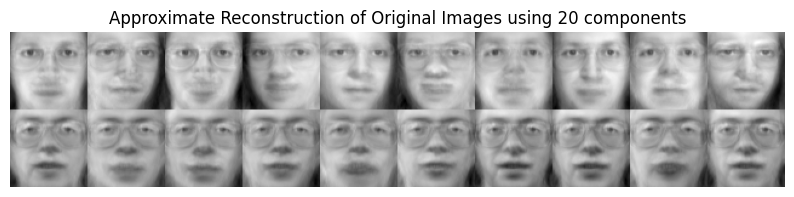

In [15]:
Z = pca.transform(X)  # principal component scores of the original images, shape: (n_samples, n_components)
X_approx = pca.inverse_transform(Z) # reconstructed images from the principal component scores.

# Display the approximate reconstruction of the original images using the montage function
montage_approx = build_montage(X_approx, img_h, img_w, m, n)
plt.figure(figsize=(10, 10))
plt.imshow(montage_approx, cmap='gray')
plt.axis('off')
plt.title('Approximate Reconstruction of Original Images using {} components'.format(n_components))
plt.show()

In [33]:
def build_montage(X, img_h, img_w, m, n):
    """
    Rearrange a flattened image array X (N x (img_h*img_w)) into an
    m x n montage matrix of shape (m*img_h, n*img_w).

    Parameters
    ----------
    X : np.ndarray
        Array of shape (N, img_h*img_w) containing flattened images.
    img_h, img_w : int
        Height and width of each individual image.
    m, n : int
        Number of rows and columns in the montage grid.

    Returns
    -------
    montage : np.ndarray
        2D array of shape (m*img_h, n*img_w) representing the montage.
    """
    assert m * n <= X.shape[0], f"m*n ({m*n}) exceeds number of images in X ({X.shape[0]})"
    grid = X[:m * n].reshape(m, n, img_h, img_w)
    montage = grid.transpose(0, 2, 1, 3).reshape(m * img_h, n * img_w)
    return montage

In [38]:
import scipy.io
import numpy as np

D = scipy.io.loadmat('data/allFaces.mat')
X = D['faces'].T # (samples, features)
k = np.ndarray.flatten(D['nfaces']) # number of images per person
y = np.repeat(np.arange(len(k)), k) # make target labels
y = y.astype('int') # make the labels integer type
img_w = D['m'].item() # width of the images
img_h = D['n'].item() # height of the images



In [39]:
# reshape each row of X into (img_w, img_h) and then transpose it to (img_h, img_w) for proper display. 
# finally, reshape back to (1, img_h*img_w) for each image. This is necessary because the images are stored in a flattened format in X, and we need to reshape them to their original dimensions for visualization. The transpose operation is used to correct the orientation of the images, as they may be stored in a different order than expected.
import pickle

X_reshaped = X.reshape(-1, img_w, img_h).transpose(0, 2, 1).reshape(-1, img_h * img_w)
X = X_reshaped
# save X, y, and img_w and img_h into a dictionary for later use
data_dict = {'X': X, 'y': y, 'img_w': img_w, 'img_h': img_h}

# save the dictionary to a file
with open('data/YaleFaces.pkl', 'wb') as f:
    pickle.dump(data_dict, f)


In [40]:
# open and read data/YaleFaces.pkl
import pickle

with open('data/YaleFaces.pkl', 'rb') as f:
    data_dict = pickle.load(f)

X = data_dict['X']
y = data_dict['y']
img_w = data_dict['img_w']
img_h = data_dict['img_h']

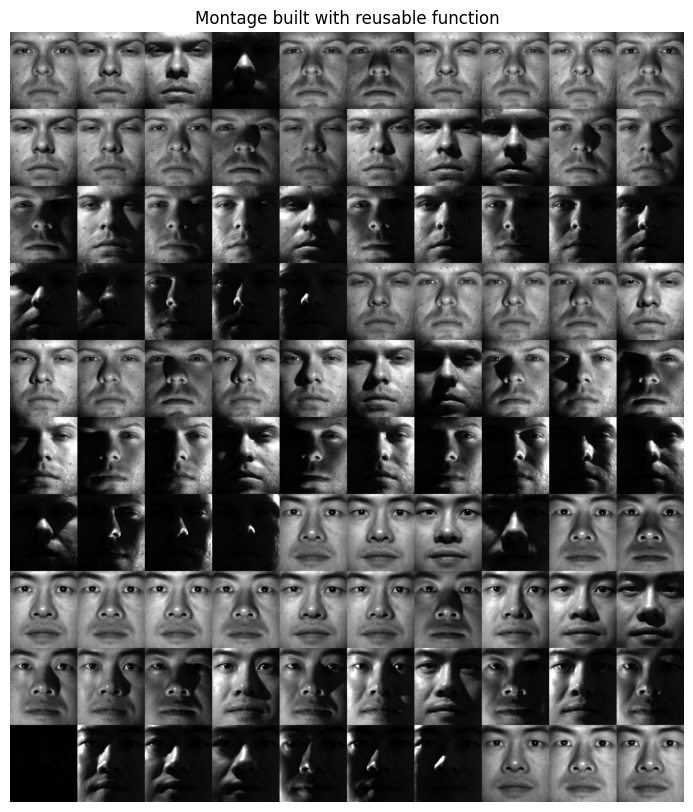

In [41]:
m, n = 10, 10
montage_2 = build_montage(X, img_h, img_w, m, n)
plt.figure(figsize=(10, 10))
plt.imshow(montage_2, cmap='gray')
plt.axis('off')
plt.title("Montage built with reusable function")
plt.show()